# Core Aspects of MLOps

1. **Data Management**
    - End to end flow of data which have 3 stages
    1. Data Ingestion: load data from files, cloud, dbs, api etc
    2. Data Transformation: perform data cleaning and transformations on this data
    3. Data Storage: store transformed data to cloud or dbs

2. **Modular Coding** Build reusable, testable pipeline components (data ingections, data transformation, model training etc) of ML project using OOPs principles

3. **Versioning** Track every change in code, datasets, and models so you can reproduce any experiment or rollback instantly using tools like github, dvc and mlflow

4. **Experiment tracking**  Log every run's parameters, metrics, and artifacts so we never lose which experiment actually worked and compare the performance

5. **CI/CD** Automate testing and packaging, then deploy anywhere with consistent, containerized environments using tools like github actions, docker etc.

6. **Monitoring** Keep a live pulse on model performance and trigger automated retraining (CT) when metrics degrade using tools like Grafana/Prometheus

7. **Infrastructure management** Provision and scale cloud or on-prem resources efficiently, ensuring cost-effectiveness and reliability.

8. **Governance and Ethics** Enforce data privacy, model fairness, and audit trails so your ML systems are compliant and trustworthy.

# ML Pipelines

- Its not a good idea to write complete code in single file instead create seperate components of each stage
- Create dvc pipeline to execute all sequentially 1 by 1

1. Data Ingestion
2. Data Preprocessing
3. Feature Engineering
4. Model training
5. Model Evaluation

**Initial setup**

1. create a project folder
2. SRC, dvc.yaml, params.yaml
3. git init && dvc init

**Build ML components in src folder**
1. Data Ingestion (load data and perform some basic cleaning and save data)
2. Data Preprocessing (perform processing)
3. Feature Engineering
4. Model Trainer
5. Model evaluation


1. Create dvc.yaml and run dvc repro
2. Integrate params.yaml and re-run ---> Benefits of params.yaml is that we dont need to change anything in code, we can just change the params values from params.yaml and re-produce the results
3. Add exception handling, logging, write functions, type hinting --> write modular code
4. Create project folder using cookiecutter or project template

# Version Control (Code and Data)

- Code versioning & Data versioning
- Code versioning can be done using git on github and for data versioning, we can use dvc
- To integrate code version control:
    1. create venv
    2. add .gitignore file
    3. git init
    4. create github repo or connect existing repo to github
    5. push code
    6. create venv and requirements.txt
    7. dvc init
    8. run dvc repro
- To integrate data versioning using dvc:
    - git cannot store huge data we use dvc
    - for code we have github, for data we can have a data repo : local dbs or cloud dbs
    - dvc will create a **metadata file** of the data file which will have a size of data, hash key etc all details about data
    - we push this metadata file which is very small size along with code on github and data file on data repo
    - when we want to restore our previous code and data file, we can do **git pull** which will pull the code and metadata file of data
    - and **dvc pull** which will pull the correct data file based on metadata file related to that code
    
    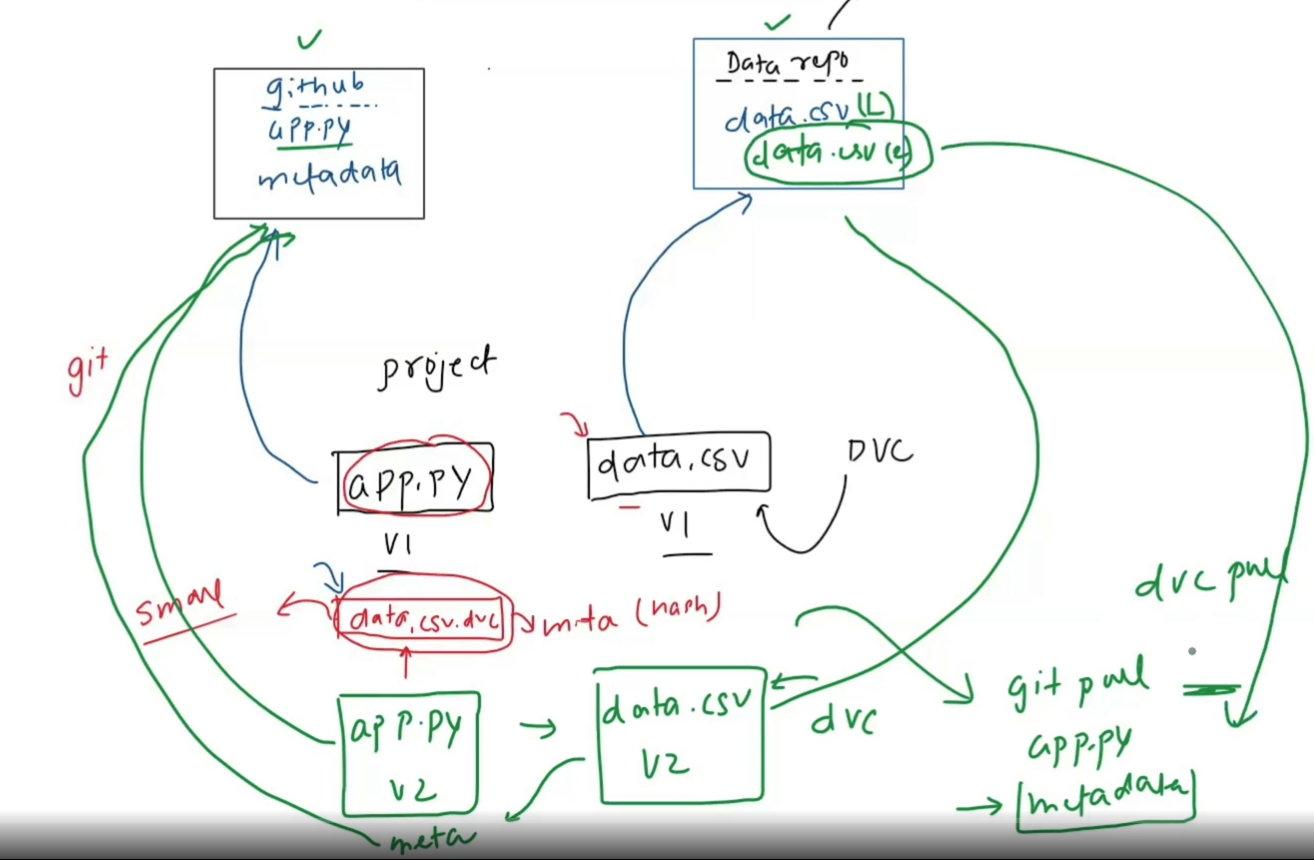

    - **commands**
        1. Add a remote storage
            - dvc remote add -d local C:/Users/iampr/AppData/Local/Temp/dvc-storage
            - dvc remote add -d s3remote s3://your-bucket-name/dvc-store (-d means use this as default)

        2. Push sequence: git add . --> git commit -m "Your commit message here" --> git push --> dvc push
        3. Pull sequence: git pull && dvc pull


    ```
    (venv) D:\ML Project\campusx_mlops\ml-pipeline-demo>dvc repro --force
    Running stage 'data_ingestion':
    > python src/1_data_ingestion.py
    D:\ML Project\campusx_mlops\ml-pipeline-demo\src\1_data_ingestion.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
    df['sentiment'] = df['sentiment'].replace({'sadness': 0, 'happiness': 1})
    D:\ML Project\campusx_mlops\ml-pipeline-demo\src\1_data_ingestion.py:36: SettingWithCopyWarning:
    A value is trying to be set on a copy of a slice from a DataFrame.
    Try using .loc[row_indexer,col_indexer] = value instead

    See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
    df['sentiment'] = df['sentiment'].replace({'sadness': 0, 'happiness': 1})
    Updating lock file 'dvc.lock'

    Running stage 'data_preprocessing':
    > python src/2_data_preprocessing.py
    [nltk_data] Downloading package stopwords to
    [nltk_data]     C:\Users\iampr\AppData\Roaming\nltk_data...
    [nltk_data]   Package stopwords is already up-to-date!
    [nltk_data] Downloading package wordnet to
    [nltk_data]     C:\Users\iampr\AppData\Roaming\nltk_data...
    [nltk_data]   Package wordnet is already up-to-date!
    Updating lock file 'dvc.lock'

    Running stage 'text_vectorization':
    > python src/3_feature_engineering.py
    Updating lock file 'dvc.lock'

    Running stage 'model_trainer':
    > python src/4_model_trainer.py
    Updating lock file 'dvc.lock'

    Running stage 'model_evaluation':
    > python src/5_model_evaluation.py
    ==================================================
    MODEL EVALUATION PIPELINE
    ==================================================
    ✓ Model loaded from: artifacts/model/logistic_regression_model.pkl
    ✓ Test data loaded: 2976 samples, 25 features

    ==================================================
    EVALUATION RESULTS
    ==================================================
    Accuracy:  0.6307
    Precision: 0.7007
    Recall:    0.4735
    AUC:       0.6962
    ==================================================
    ✓ Metrics saved to: reports/metrics.yaml
    ✓ Experiment info saved to: reports/experiment_info.json

    ✓ Model evaluation completed successfully!
    Updating lock file 'dvc.lock'

    To track the changes with git, run:

            git add dvc.lock

    To enable auto staging, run:

            dvc config core.autostage true
    Use `dvc push` to send your updates to remote storage.

    (venv) D:\ML Project\campusx_mlops\ml-pipeline-demo>git status
    On branch main
    Your branch is up to date with 'origin/main'.

    Changes not staged for commit:
    (use "git add <file>..." to update what will be committed)
    (use "git restore <file>..." to discard changes in working directory)
            modified:   .dvc/config
            modified:   .gitignore
            modified:   dvc.lock
            modified:   params.yaml
            modified:   src/3_feature_engineering.py
            modified:   src/__pycache__/mylogging.cpython-310.pyc

    Untracked files:
    (use "git add <file>..." to include in what will be committed)
            requirements.txt

    no changes added to commit (use "git add" and/or "git commit -a")

    (venv) D:\ML Project\campusx_mlops\ml-pipeline-demo>git add .

    (venv) D:\ML Project\campusx_mlops\ml-pipeline-demo>git commit -m "added s3 remote"
    [main e103923] added s3 remote
    7 files changed, 62 insertions(+), 48 deletions(-)
    create mode 100644 requirements.txt

    (venv) D:\ML Project\campusx_mlops\ml-pipeline-demo>git push && dvc push
    Enumerating objects: 22, done.
    Counting objects: 100% (22/22), done.
    Delta compression using up to 4 threads
    Compressing objects: 100% (11/11), done.
    Writing objects: 100% (12/12), 1.52 KiB | 259.00 KiB/s, done.
    Total 12 (delta 6), reused 0 (delta 0), pack-reused 0 (from 0)
    remote: Resolving deltas: 100% (6/6), completed with 6 local objects.
    To https://github.com/iamprashantjain/ml-pipeline-demo-v1.git
    4229591..e103923  main -> main
    Collecting                                                                                                                                                                                                        |10.0 [00:00,  213entry/s]
    Pushing
    10 files pushed
    ```

# Experiment Tracking

- **Comprehensive logging of all experimental metadata throughout the model development lifecycle, including:**

    1. Hyperparameters – Learning rates, batch sizes, optimizer configurations, regularization parameters, and model architecture settings
    2. Datasets – Data sources, versioning, preprocessing steps, augmentation techniques, and train/validation/test splits
    3. Code Versions – Git commit hashes, branch names, repository URLs, and any uncommitted changes or patches
    4. Environment – Operating system, Python versions, dependency libraries (with exact versions), CUDA setups, and hardware specifications
    5. Performance Metrics – Training/validation losses, accuracy, precision, recall, F1-score, AUC-ROC, inference latency, and model size
    6. Artifacts – Model weights, visualization outputs (confusion matrices, feature importance plots), sample predictions, and training logs

- **benefits:**
    1. Reproducibility – Recreate any experiment precisely, eliminating the "works on my machine" problem and ensuring consistent results across team members and time
    2. Comparative Analysis – Visualize and compare multiple runs side-by-side to identify which configurations yield optimal performance
    3. Team Collaboration – Enable seamless knowledge sharing, prevent redundant work, and allow team members to build upon each other's experiments
    4. Actionable Insights – Uncover patterns and correlations (e.g., "batch size 64 consistently outperforms 256"), leading to more informed modeling decisions
    5. Audit & Compliance – Maintain transparent records for regulatory requirements (GDPR, HIPAA, financial audits) and document which model versions were deployed and why

- **Tools**
    1. mlflow (experiment tracking & model registry)
    2. weights & biases
    3. neptune
    4. comet
    5. dvc

## MLFlow

**ML Workflow**

1. Conduct systematic experiments with MLflow to identify the best model and hyperparameters through baseline modeling, algorithm selection, and hyperparameter tuning.
2. Deploy mlflow experiments to Dagshub or AWS so that everybody can see it
3. Transform the winning experiment into a reproducible DVC pipeline with versioned data, parameterized stages, and tracked metrics for one-command reproducibility (dvc repro).
4. Automate model validation and registration by running DVC pipeline on code changes, validating performance thresholds, and pushing approved models to MLflow Model Registry.
5. Deploy registered models to production using AWS SageMaker endpoints, Lambda functions, or S3 with blue-green deployment and automatic rollback capabilities.
6. Monitor production models for data/concept drift, trigger automated retraining when performance degrades, validate new models against the champion, and seamlessly promote superior models to production.


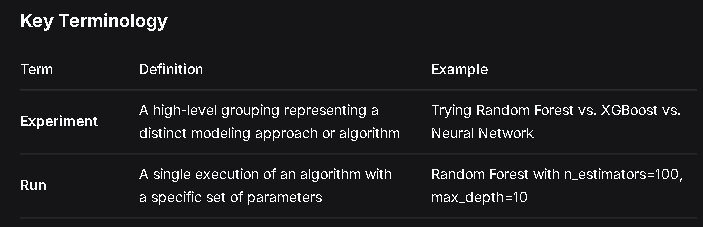

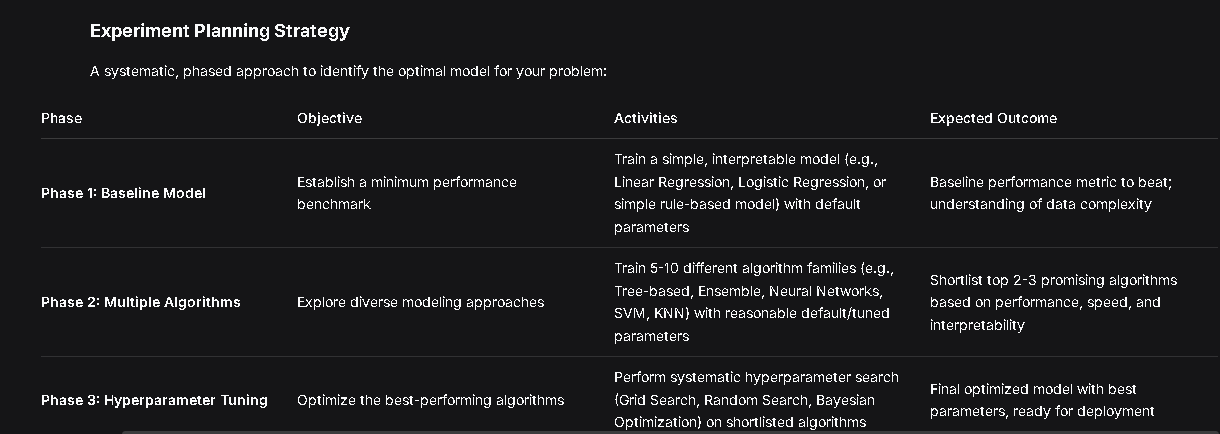

- when we run mlflow it will create a folder called "mlruns"
- this file will meta details about all the experiments

- **Sample Code**

    ```
    import mlflow
    import mlflow.sklearn
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import accuracy_score, confusion_matrix
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Set/create new experiment
    mlflow.set_tracking_uri("https://dagshub.com/iamprashantjain/Swiggy-Delivery-Time-Prediction.mlflow")

    os.environ["MLFLOW_TRACKING_USERNAME"] = os.getenv("MLFLOW_TRACKING_USERNAME", "iamprashantjain")
    os.environ["MLFLOW_TRACKING_PASSWORD"] = os.getenv("MLFLOW_TRACKING_PASSWORD", "")
    
    mlflow.set_experiment("base_model")

    max_depth = 5
    n_estimators = 100

    with mlflow.start_run(run_name='prashant_exp1') as run:
        
        model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth)
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        
        # Log params
        mlflow.log_param('n_estimators', n_estimators)
        mlflow.log_param('max_depth', max_depth)
        
        # Log metrics
        mlflow.log_metric('accuracy', accuracy)
        
        # Log artifacts
        # Create confusion matrix plot
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title('Confusion Matrix')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.savefig('confusion_matrix.png')
        mlflow.log_artifact('confusion_matrix.png')
        plt.close()

        #log current code file
        mlflow.log_artifact(__file__)
        
        # Log model
        mlflow.sklearn.log_model(model, "random_forest_model")

        #set tags
        mlflow.set_tag('author','prashantjain')
        mlflow.set_tag('model','RandomForestClassifier')

        #log dataset
        #merging train & test data
        train_df = X_train
        train_df['variety'] = y_train

        test_df = X_test
        test_df['variety'] = y_test

        #converting dataset into mlflow acceptable format
        train_df = mlflow.data.from_pandas(train_df)
        test_df = mlflow.data.from_pandas(test_df)

        mlflow.log_input(train_df, context='training')
        mlflow.log_input(test_df, context='validation')
    ```

- We can also use mlflow.auto_log() to be defined at the top to log everything automatically
- It will log:
    1. metrics
    2. parametres
    3. model signature
    4. artifacts
    5. dataset

- **What can mlflow track**

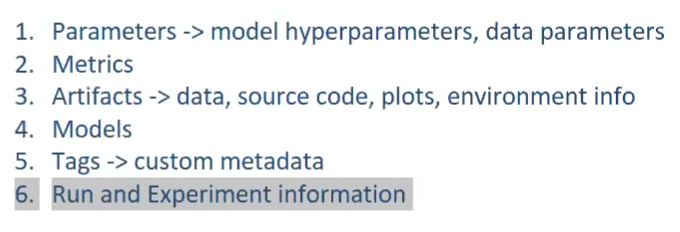

- **To perform hyper-parameter tuning with MLflow** using nested runs, you'll create a parent run for the overall tuning process and child runs for each parameter combination trial. The nested=True parameter in mlflow.start_run() is the key to establishing this hierarchical relationship

    ```
    import mlflow
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.datasets import make_classification
    from sklearn.model_selection import cross_val_score
    import numpy as np

    # Generate data
    X, y = make_classification(n_samples=200, n_features=10, random_state=42)

    # Hyperparameters to test
    params_grid = [
        {"n_estimators": 50, "max_depth": 3},
        {"n_estimators": 100, "max_depth": 5},
        {"n_estimators": 150, "max_depth": 7},
    ]

    # Parent run
    with mlflow.start_run(run_name="tuning_parent") as parent:
        best_score = 0
        best_params = None
        
        # Child runs (nested)
        for params in params_grid:
            with mlflow.start_run(nested=True, run_name=f"trial_{params}") as child:
                # Log params for this trial
                mlflow.log_params(params)
                
                # Train and evaluate
                model = RandomForestClassifier(**params, random_state=42)
                score = np.mean(cross_val_score(model, X, y, cv=3))
                
                # Log metric
                mlflow.log_metric("cv_score", score)
                
                # Track best
                if score > best_score:
                    best_score = score
                    best_params = params
        
        # Log best to parent
        mlflow.log_metric("best_cv_score", best_score)
        mlflow.log_params({f"best_{k}": v for k, v in best_params.items()})
        
        print(f"Best: {best_params} with score {best_score:.3f}")
    ```

# Model Registry

- A Model Registry is a centralized repository that stores, versions, and manages ML models throughout their lifecycle. Just like GitHub tracks code changes, a model registry tracks:

    1. Model versions (v1, v2, v3)
    2. Model metadata (parameters, metrics, training data)
    3. Model artifacts (serialized model files)
    4. Model lineage (which code/data produced this model)
    5. Model stages (Staging, Production, Archived)

- Model Registry is indeed the crucial bridge between Data Science (development) and Ops (production) in the MLOps lifecycle.
- All machine learning development happens here - experimentation, training, tuning, and evaluation. This ends when the model is pushed to production in model registry.
- After the model is in the registry, Ops takes over - deploying to production servers, monitoring performance, and maintaining the live system.

- **Stages of model**
1. Development or None: create and refine the model to get the best performance
2. Staging: Transition model from development to staging, perform UAT tests
3. Production: Transition model from development to production, now Ops team will deploy this model in production, Monitoring is also established to Monitor model performance
4. Archive/Retire: When model performance degrades, we will retire this model and deploy new model following all above steps


```
from mlflow.tracking import MlflowClient
import mlflow

client = MlflowClient()

#run id of the run where model was logged
run_id = "6707d37f29bf4af994be9515f6c014f8"

#model_path
model_path = "mlflow-artifacts:/5ab3b8ab878949c7b7c5cc0e1419a7e0/models/m-b57e97e335a94bf7ad745ec9d7008848/artifacts/model.pkl"

#model_uri
model_uri = f"runs:/{run_id}/{model_path}


#register model
model_name = "model"
result = mlflow.register_model(model_uri, model_name)


#description
client.update_model_version(
    name = model_name,
    version = result.version,
    description = "this is a test model"
)

client.set_model_version_tag(
    name = model_name,
    version = result.version,
    keys = "experiment",
    value = "twitter emotions"
)
```

# CI/CD Pipeline

- Generate requirements.txt
- Add **ci.yaml** inside .github\workflows
- Add **DAGSHUB_TOKEN** in secret variables in github repo
- CI Steps:
    1. setup running dvc pipeline on git push
    2. tests (model test & performance)
    3. if test success: promote model to production
    4. flask/fast api testing
    5. dockerize flask app & push to ecr
    6. deploy docker image on ecr to aws

# Docker

- Docker is a platform that enables developers to build, share, and run applications inside containers - lightweight, portable environments that package everything needed to run the software consistently.

**Understanding Docker through an Analogy: Maggi Noodles**
  - A pack of Maggi noodles has **two main components**: noodles and masala (spice mix)
  - If the masala recipe varies, the same noodles will taste **different** depending on who prepares it
  - The taste becomes **inconsistent** and **unpredictable** across different kitchens
  - The Maggi manufacturer creates a **standardized "masala container"** - a pre-measured, sealed spice packet
  - This ensures that **no matter where or who cooks it**, the Maggi will taste **exactly the same** every time

**The Parallel in Software Development**
  - Software faces a similar challenge - it runs differently across environments
  - Variations in:
    - Operating systems
    - Library versions
    - Dependencies
    - Configuration settings
  - An application that works perfectly on a developer's machine may **fail** on another system
  - This leads to the infamous *"it works on my machine"* problem

- **The Solution (Containerization):**
  - Docker packages the **application** along with its:
    - Environment
    - Dependencies
    - Configuration files
    - System tools
  - This package is called a **Docker Image**
  - The image can be **run anywhere** - on any machine, cloud, or operating system
  - It will behave **identically** regardless of where it's deployed

**Key Benefits**

- **Consistency**: Same behavior across development, testing, and production
- **Portability**: Run on any system without compatibility issues
- **Isolation**: Each application runs in its own environment, avoiding conflicts
- **Reproducibility**: Others can replicate your exact setup with a single command

docker build --no-cache -t emotion1 . && docker run -p 8888:5000 -e DAGSHUB_TOKEN="YOUR_DAGSHUB_TOKEN" emotion1

# End to End ML Workflow

| Stage | What to do | Tools |
|-------|------------|-------|
| We have a ML Problem | - | - |
| Data Wrangling | Scraping data or extracting data from databases or APIs | Python & Pandas |
| Data Assessment | Assess complete data to find out what to clean and strategize | Python & Pandas |
| Data Cleaning | Clean data based on above strategy | Python & Pandas |
| EDA | Explore every column including target column and multiple columns to find relations and effect on target column | Python & Pandas |
| Another round of Data Cleaning | Clean data based on above strategy | Python & Pandas |
| Feature Engineering | Create more features if possible as understood during EDA | Python & Pandas |
| Experimentation | Perform experiments to find baseline model, best model and best hyper parameters | MLflow |
| ML Pipeline | Create reproducible ML pipeline & log model in model evaluation stage to MLflow experiment tracking | DVC |
| Register Model | Push experiment tracking model to model_registry in STAGING stage | MLflow Model Registry |
| Model_Serving | Create API around model so that it can be integrated on website and users can actually use it | FastAPI & Pydantic |
| CI | 1. Run DVC pipeline on GitHub Runner<br>2. Generate the model, log & push model to staging in model registry - so that any change in code, on git push, it should trigger DVC pipeline, and new model will be added to model_registry as staging (so that testing perform)<br>3. Test model:<br>&nbsp;&nbsp;&nbsp;- Model loading<br>&nbsp;&nbsp;&nbsp;- Model signature<br>&nbsp;&nbsp;&nbsp;- Model performance testing (like threshold > 90% or compare with existing production model)<br>4. Promote model to production<br>5. Flask app testing<br>6. Dockerize Flask app & push to ECR<br>7. Deploy docker image to AWS | github actions, docker, aws |
| CD | Once docker image is in AWS ECR, We can pull that image from ECR and deploy it to EC2 or ECS | aws ec2, codedeploy, ecs |